In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})
sns.set_theme(style="whitegrid")

In [2]:
def load_and_preprocess_data(filepath: str, is_real_dataset: bool = False) -> tuple:
    """
    Parses the dataset using the empirically observed delimiters, isolates
    feature matrices from meta-labels, and applies Z-score standardization.
    """
    # Dynamic delimiter assignment based on file inspection
    delimiter = ';' if is_real_dataset else ','
    
    df = pd.read_csv(filepath, sep=delimiter)
    
    if is_real_dataset:
        # A2-real: 5 features, 1 location, 1 class
        feature_cols = df.columns[:-2]
        X_raw = df[feature_cols].values
        metadata = {
            'labels': df.iloc[:, -1].values,
            'locations': df.iloc[:, -2].values
        }
    else:
        # A2-synthetic: 4 features, 1 class
        feature_cols = df.columns[:-1]
        X_raw = df[feature_cols].values
        metadata = {'labels': df.iloc[:, -1].values}
        
    # Apply Z-score standardization: (x - mu) / sigma
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    return X_scaled, metadata, feature_cols

# init tensor variables
X_syn, meta_syn, cols_syn = load_and_preprocess_data('A2-synthetic.txt', is_real_dataset=False)
X_real, meta_real, cols_real = load_and_preprocess_data('A2-real.txt', is_real_dataset=True)

print(f"Synthetic tensor -> X shape: {X_syn.shape} (Expected: 360, 4)")
print(f"Real tensor      -> X shape: {X_real.shape} (Expected: 333, 5)")

Synthetic tensor -> X shape: (360, 4) (Expected: 360, 4)
Real tensor      -> X shape: (333, 5) (Expected: 333, 5)


--- PCA Analysis: Synthetic Dataset ---


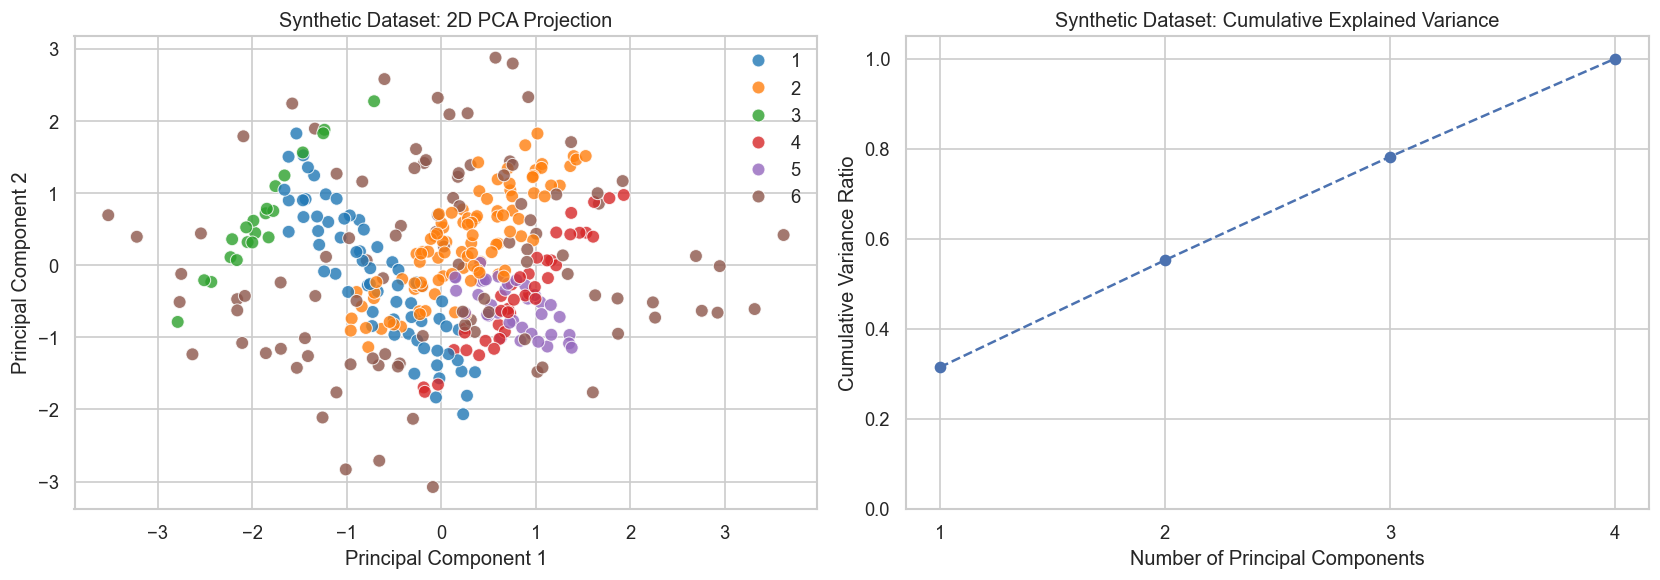


--- PCA Analysis: Real Dataset ---


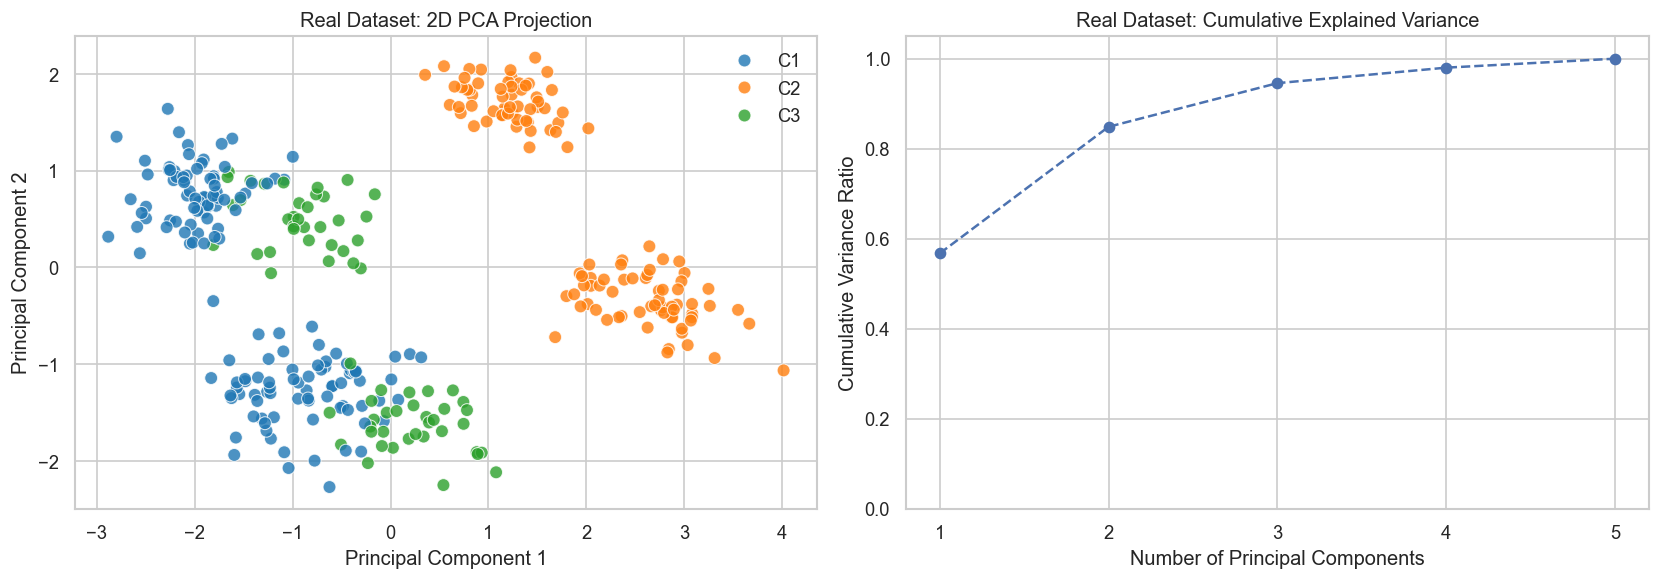

In [3]:
#PCA
from sklearn.decomposition import PCA

def execute_pca_pipeline(X: np.ndarray, labels: np.ndarray, dataset_name: str) -> np.ndarray:
    """
    Computes PCA transformation, plots the 2D projection colored by class,
    and generates the cumulative explained variance scree plot.
    """
    # Instantiate PCA keeping all components to calculate full variance spectrum
    pca = PCA()
    X_pca_full = pca.fit_transform(X)

    # 2D projection requirement
    X_pca_2d = X_pca_full[:, :2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: 2D Latent Space Projection
    sns.scatterplot(
        x=X_pca_2d[:, 0],
        y=X_pca_2d[:, 1],
        hue=labels,
        palette='tab10',
        ax=axes[0],
        s=60,
        alpha=0.8,
        legend='full'
    )
    axes[0].set_title(f'{dataset_name}: 2D PCA Projection')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')

    # Plot 2: Scree Plot (Cumulative Variance)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
    axes[1].set_title(f'{dataset_name}: Cumulative Explained Variance')
    axes[1].set_xlabel('Number of Principal Components')
    axes[1].set_ylabel('Cumulative Variance Ratio')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xticks(range(1, len(cumulative_variance) + 1))

    plt.tight_layout()
    plt.show()

    return X_pca_2d

print("--- PCA Analysis: Synthetic Dataset ---")
X_syn_pca = execute_pca_pipeline(X_syn, meta_syn['labels'], "Synthetic Dataset")

print("\n--- PCA Analysis: Real Dataset ---")
X_real_pca = execute_pca_pipeline(X_real, meta_real['labels'], "Real Dataset")

--- t-SNE Optimization: Synthetic Dataset ---


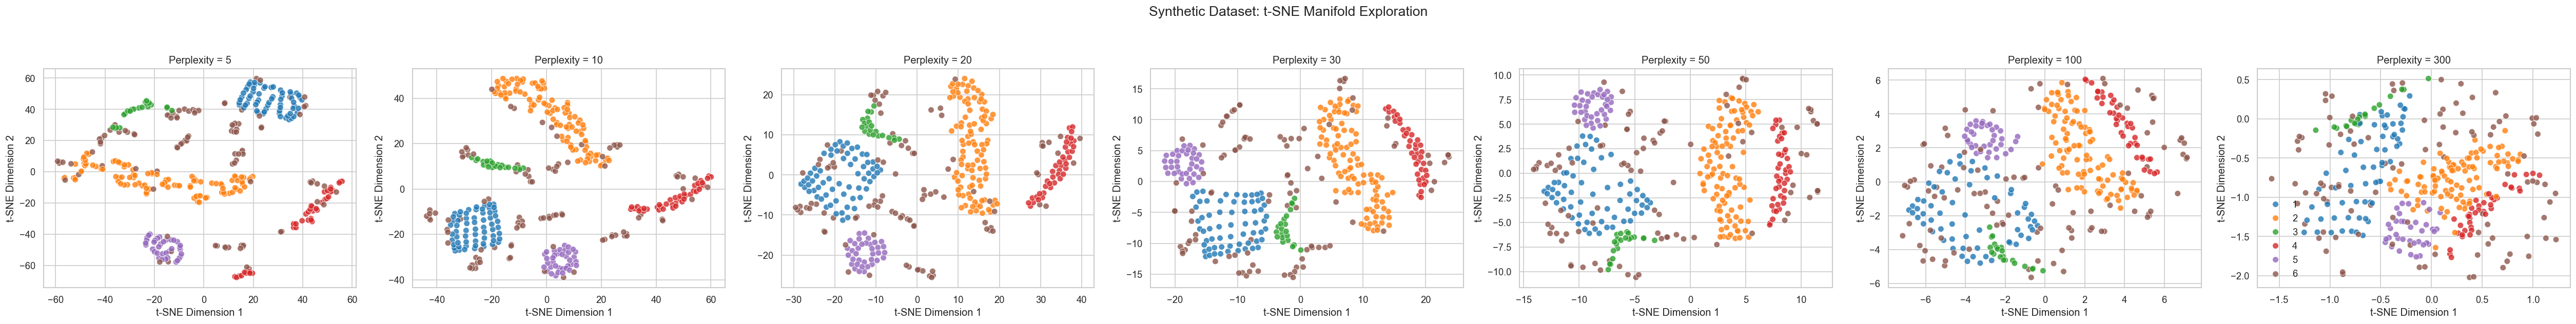


--- t-SNE Optimization: Real Dataset ---


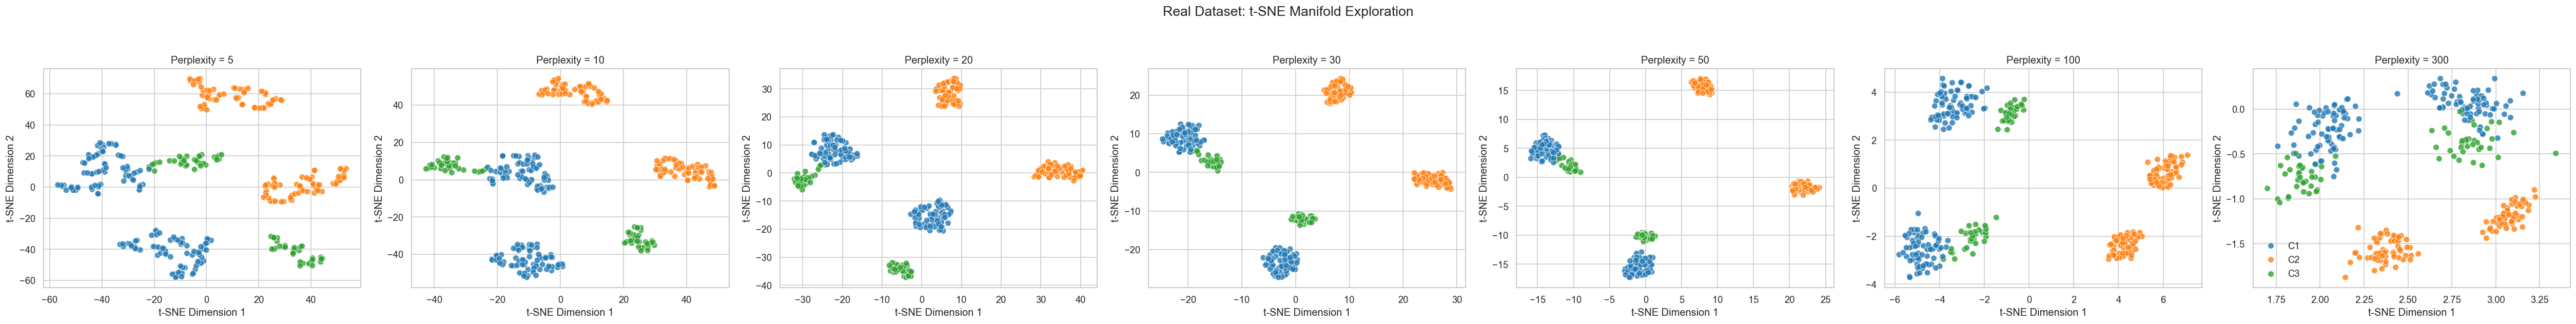

In [4]:
#t-SNE
from sklearn.manifold import TSNE

def evaluate_tsne_perplexities(X: np.ndarray, labels: np.ndarray, dataset_name: str, perplexities: list, save_dir: str = './plots'):
    """
    Computes and plots t-SNE 2D projections for a given list of perplexity values.
    Demonstrates the impact of the effective neighborhood size on local topology.
    """
    n_plots = len(perplexities)
    # Define a 1xN grid for the subplots based on the number of perplexities
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

    if n_plots == 1:
        axes = [axes] # ensure iterable if only one perplexity is passed

    for i, perplexity in enumerate(perplexities):
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            random_state=42,
            init='pca',
            learning_rate='auto'
        )

        # fit and transform the standardized feature matrix
        X_tsne = tsne.fit_transform(X)

        # plot the 2D latent space
        sns.scatterplot(
            x=X_tsne[:, 0],
            y=X_tsne[:, 1],
            hue=labels,
            palette='tab10',
            ax=axes[i],
            s=50,
            alpha=0.8,
            legend='full' if i == n_plots - 1 else False
        )

        axes[i].set_title(f'Perplexity = {perplexity}')
        axes[i].set_xlabel('t-SNE Dimension 1')
        axes[i].set_ylabel('t-SNE Dimension 2')

    fig.suptitle(f'{dataset_name}: t-SNE Manifold Exploration', fontsize=16, y=1.05)
    plt.tight_layout()

    filename = f"{dataset_name.replace(' ', '_').lower()}_tsne_grid.png"
    filepath = os.path.join(save_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

# define hyperparameter grid: extremely local, standard, and global limits
perplexity_grid = [5, 10, 20, 30, 50, 100, 300]

print("--- t-SNE Optimization: Synthetic Dataset ---")
evaluate_tsne_perplexities(X_syn, meta_syn['labels'], "Synthetic Dataset", perplexity_grid)

print("\n--- t-SNE Optimization: Real Dataset ---")
evaluate_tsne_perplexities(X_real, meta_real['labels'], "Real Dataset", perplexity_grid)

--- K-Means Evaluation: Synthetic Dataset ---


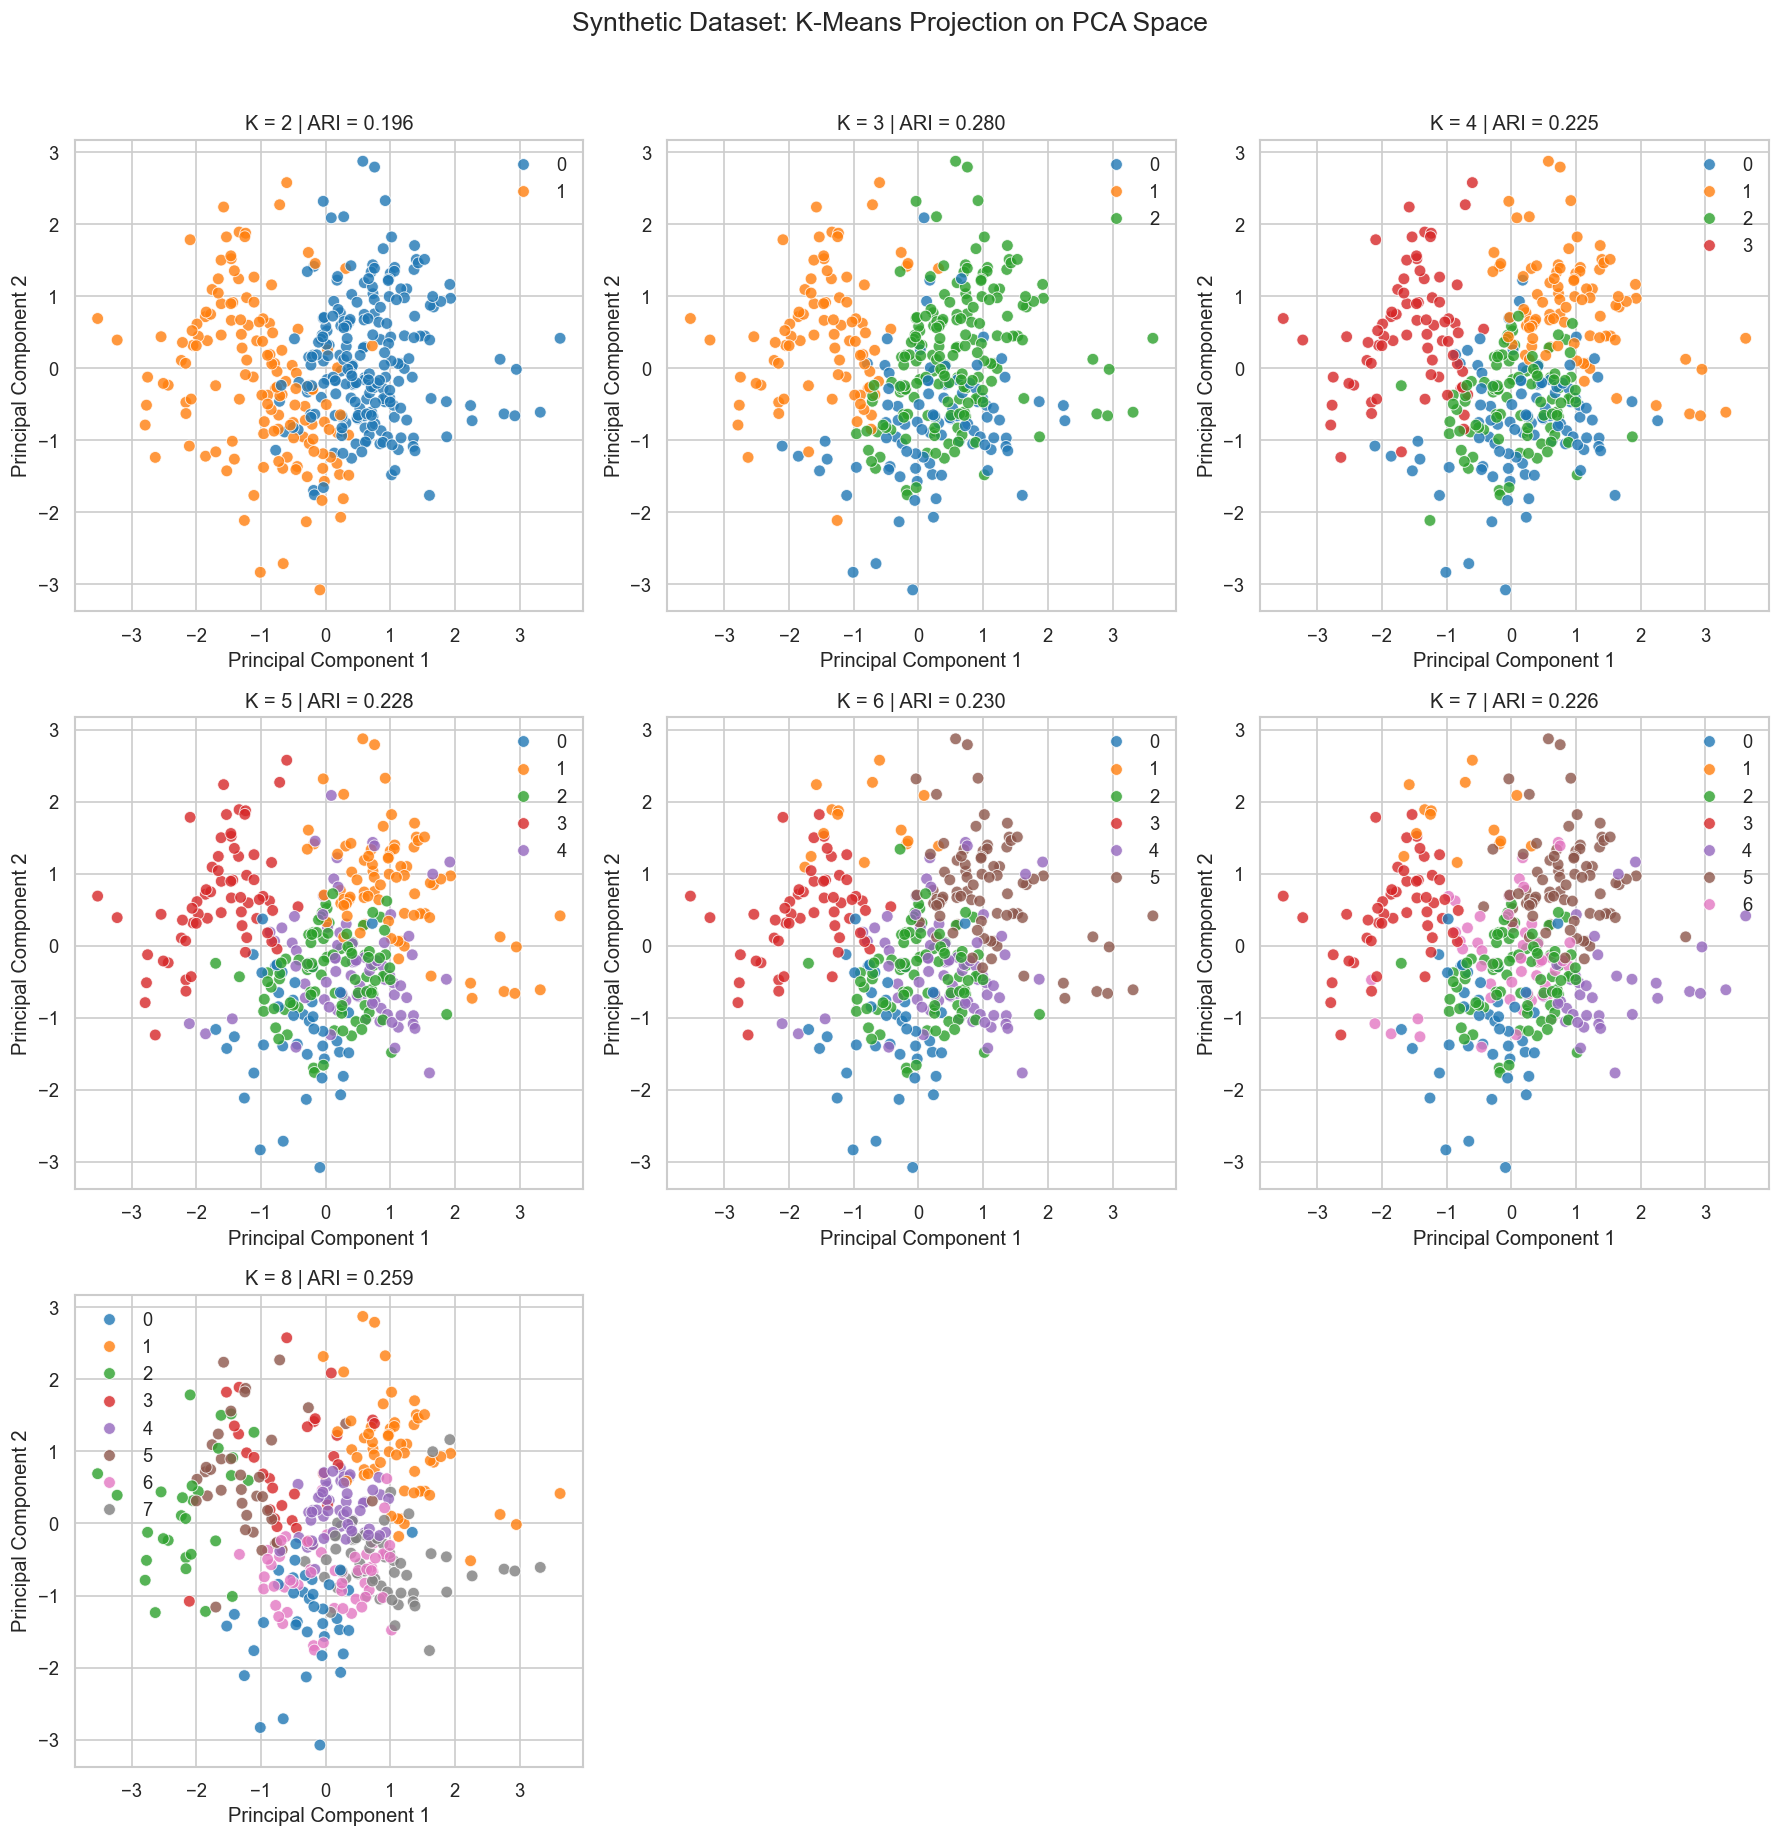

--- ARI Benchmark Summary for Synthetic Dataset ---
K = 2: ARI = 0.1957
K = 3: ARI = 0.2796
K = 4: ARI = 0.2251
K = 5: ARI = 0.2276
K = 6: ARI = 0.2296
K = 7: ARI = 0.2264
K = 8: ARI = 0.2593

--- K-Means Evaluation: Real Dataset ---


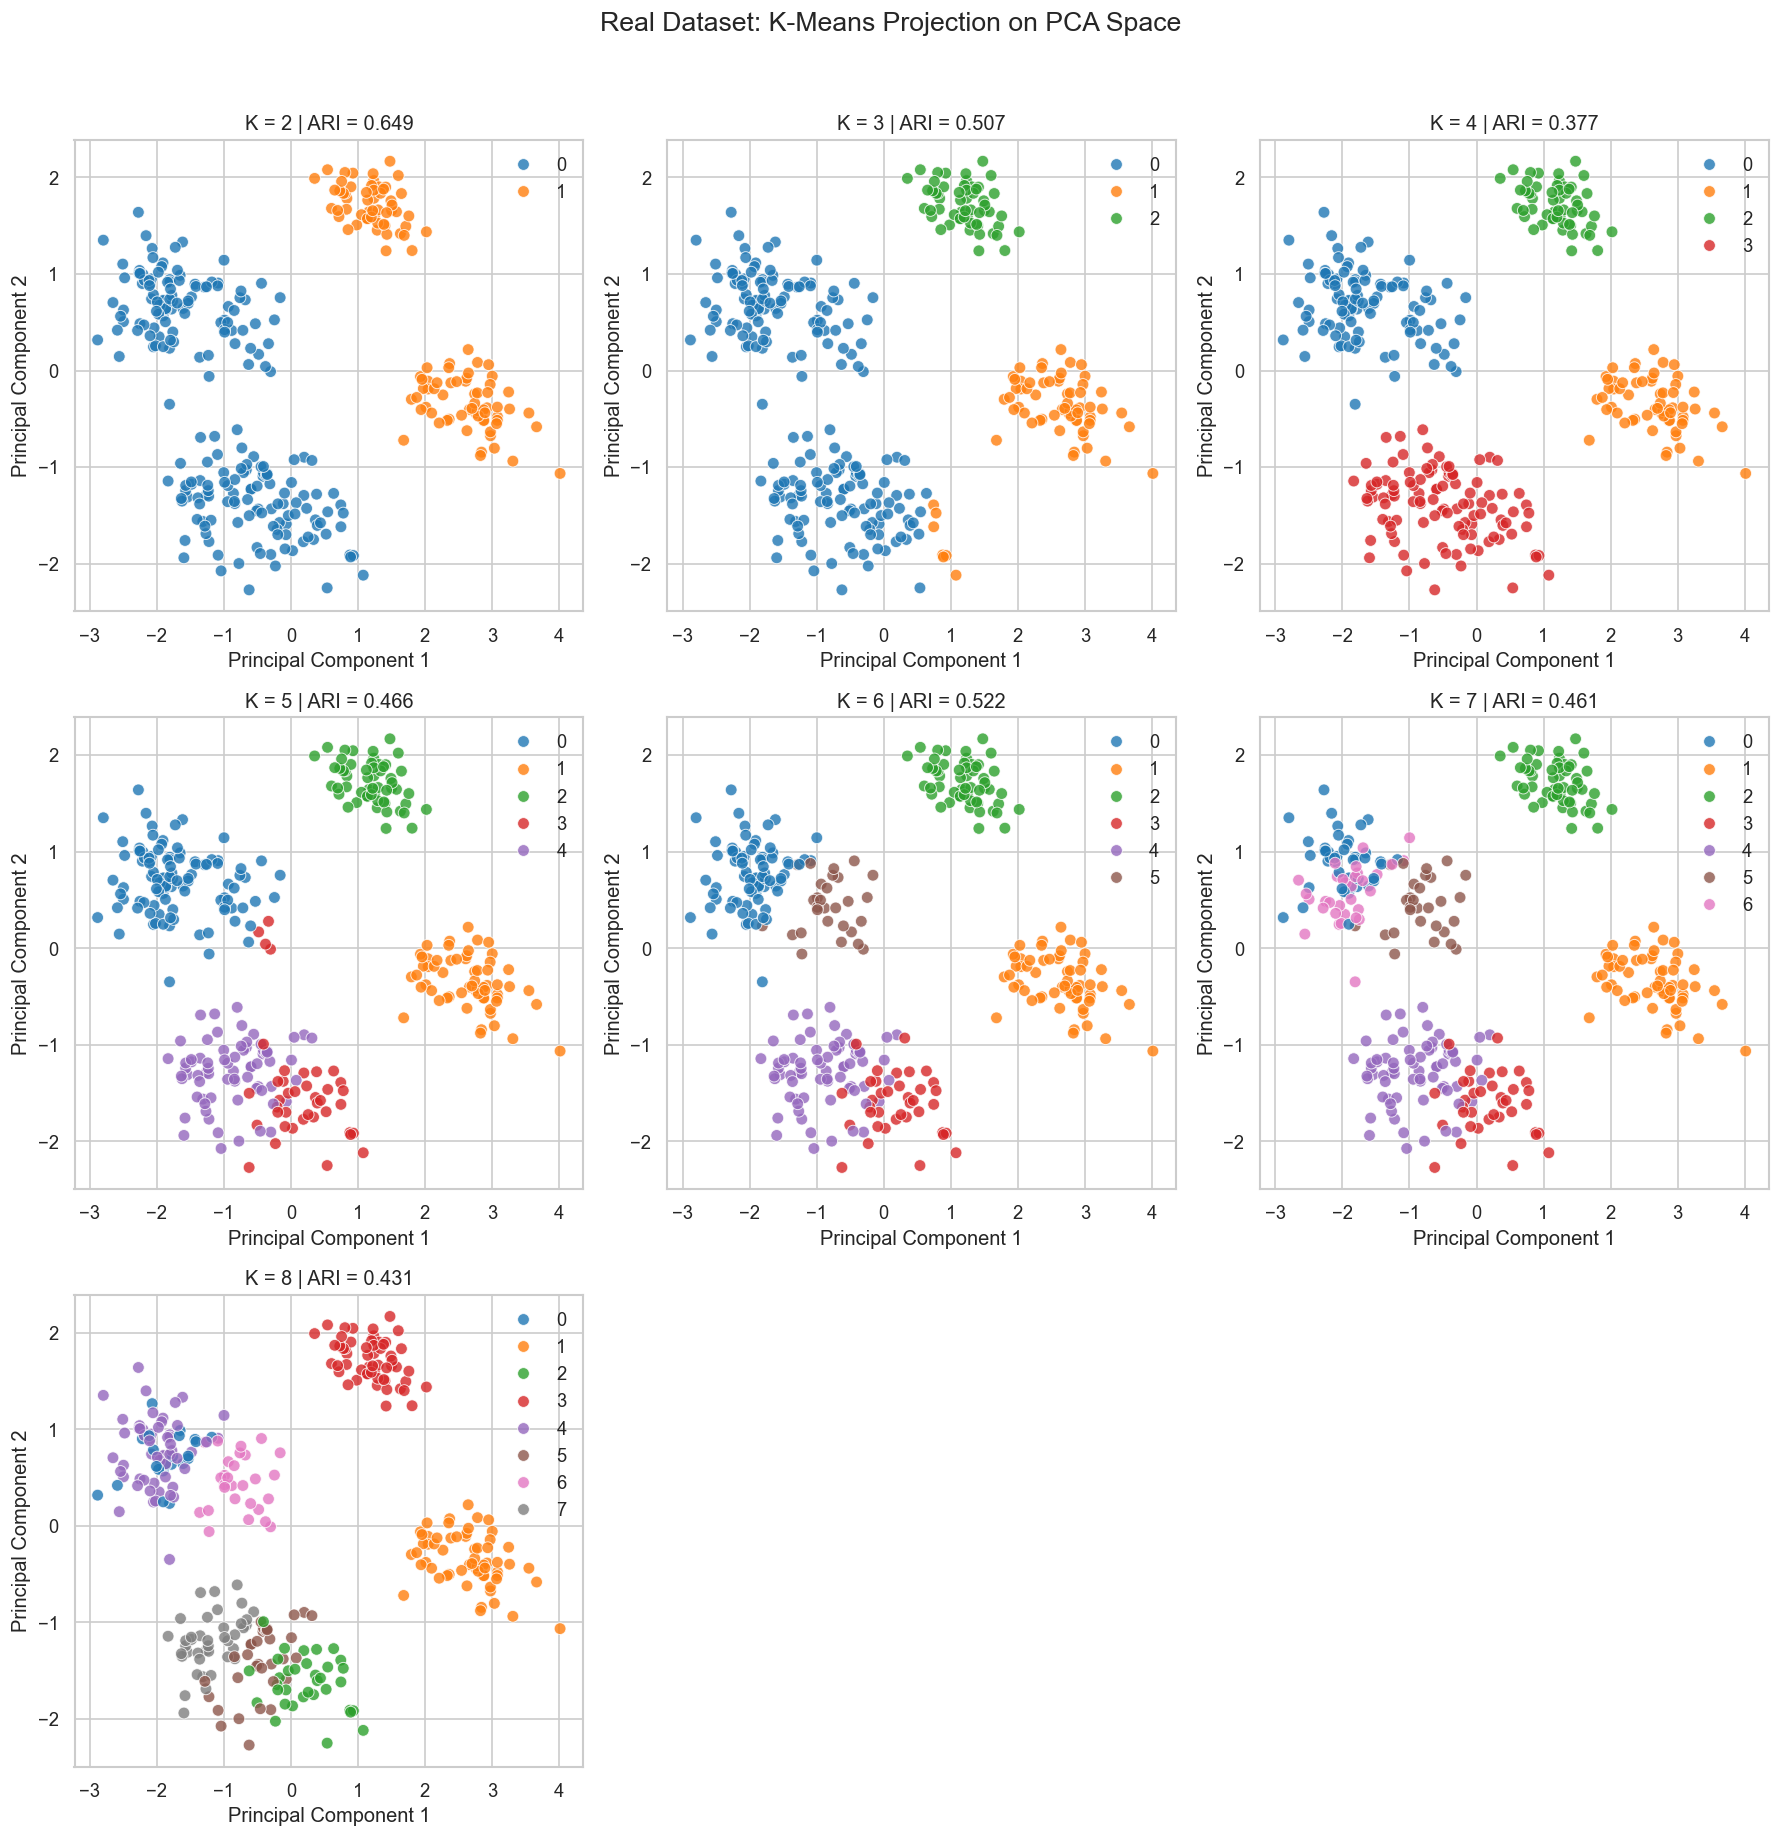

--- ARI Benchmark Summary for Real Dataset ---
K = 2: ARI = 0.6486
K = 3: ARI = 0.5069
K = 4: ARI = 0.3767
K = 5: ARI = 0.4661
K = 6: ARI = 0.5219
K = 7: ARI = 0.4611
K = 8: ARI = 0.4311


In [5]:
# k-MEANS
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def evaluate_kmeans_on_pca(X: np.ndarray, X_pca: np.ndarray, real_labels: np.ndarray, dataset_name: str, k_range: range, save_dir: str = './plots'):
    """
    Applies K-Means clustering across a range of k values, computes the Adjusted Rand Index (ARI)
    against ground truth, and plots the assigned clusters onto the 2D PCA latent space.
    """
    n_plots = len(k_range)
    # Configure dynamic grid layout. 3 plots per row max for readability.
    cols = 3
    rows = int(np.ceil(n_plots / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() # flatten to iterate easily

    ari_scores = []

    for i, k in enumerate(k_range):
        # initialize K-Means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

        # Fit on high-dimensional scaled space X, get predicted cluster assignments
        predicted_clusters = kmeans.fit_predict(X)

        # comparison: Compute ARI between true labels and K-Means clusters
        ari = adjusted_rand_score(real_labels, predicted_clusters)
        ari_scores.append((k, ari))

        # Scatter plot over PCA coordinates (from Module 3)
        sns.scatterplot(
            x=X_pca[:, 0], 
            y=X_pca[:, 1], 
            hue=predicted_clusters, 
            palette='tab10', 
            ax=axes[i], 
            s=50, 
            alpha=0.8,
            legend='full'
        )

        axes[i].set_title(f'K = {k} | ARI = {ari:.3f}')
        axes[i].set_xlabel('Principal Component 1')
        axes[i].set_ylabel('Principal Component 2')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'{dataset_name}: K-Means Projection on PCA Space', fontsize=16, y=1.02)
    plt.tight_layout()

    filename = f"{dataset_name.replace(' ', '_').lower()}_kmeans_pca.png"
    filepath = os.path.join(save_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

    # statistical summary
    print(f"--- ARI Benchmark Summary for {dataset_name} ---")
    for k, ari in ari_scores:
        print(f"K = {k}: ARI = {ari:.4f}")

    return ari_scores

# evaluate K from 2 to 8 to cover the underlying ground truth of both datasets (Synthetic has 6 true classes, Real has 3 true classes)
k_search_space = range(2, 9)

print("--- K-Means Evaluation: Synthetic Dataset ---")
ari_syn = evaluate_kmeans_on_pca(
    X=X_syn,
    X_pca=X_syn_pca,
    real_labels=meta_syn['labels'],
    dataset_name="Synthetic Dataset",
    k_range=k_search_space
)

print("\n--- K-Means Evaluation: Real Dataset ---")
ari_real = evaluate_kmeans_on_pca(
    X=X_real,
    X_pca=X_real_pca,
    real_labels=meta_real['labels'],
    dataset_name="Real Dataset",
    k_range=k_search_space
)

Plot saved successfully at: plots\synthetic_dataset_ahc.png


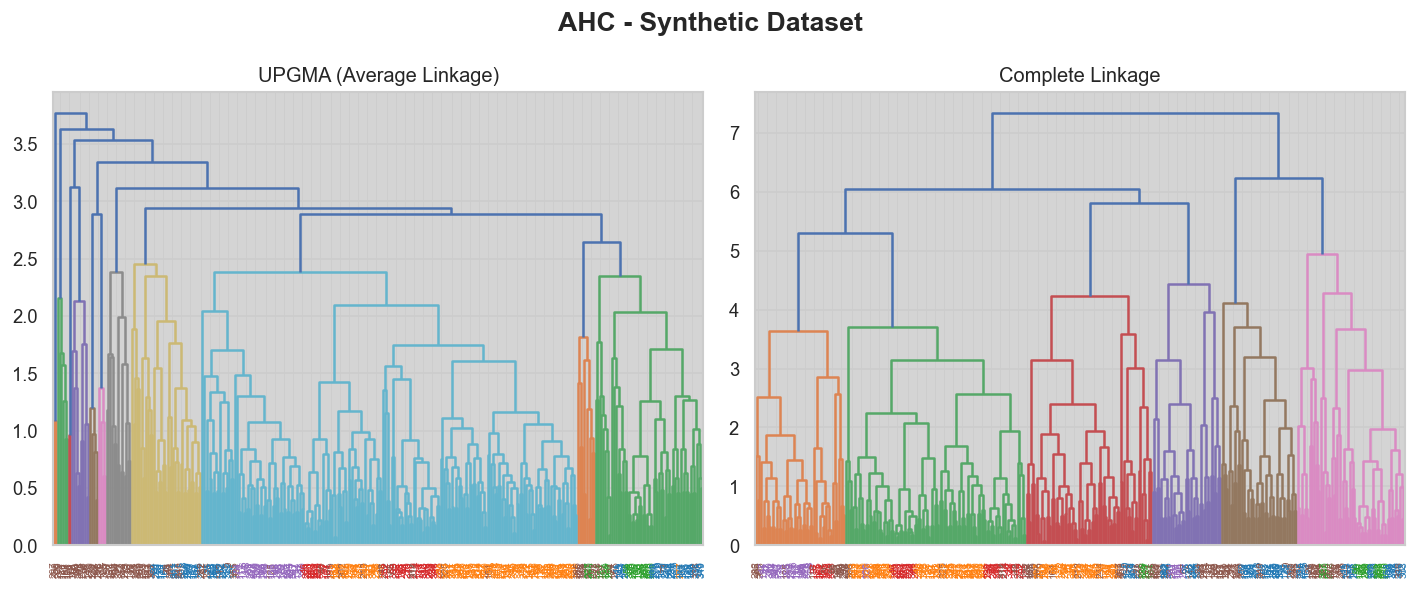

Plot saved successfully at: plots\real_dataset_ahc.png


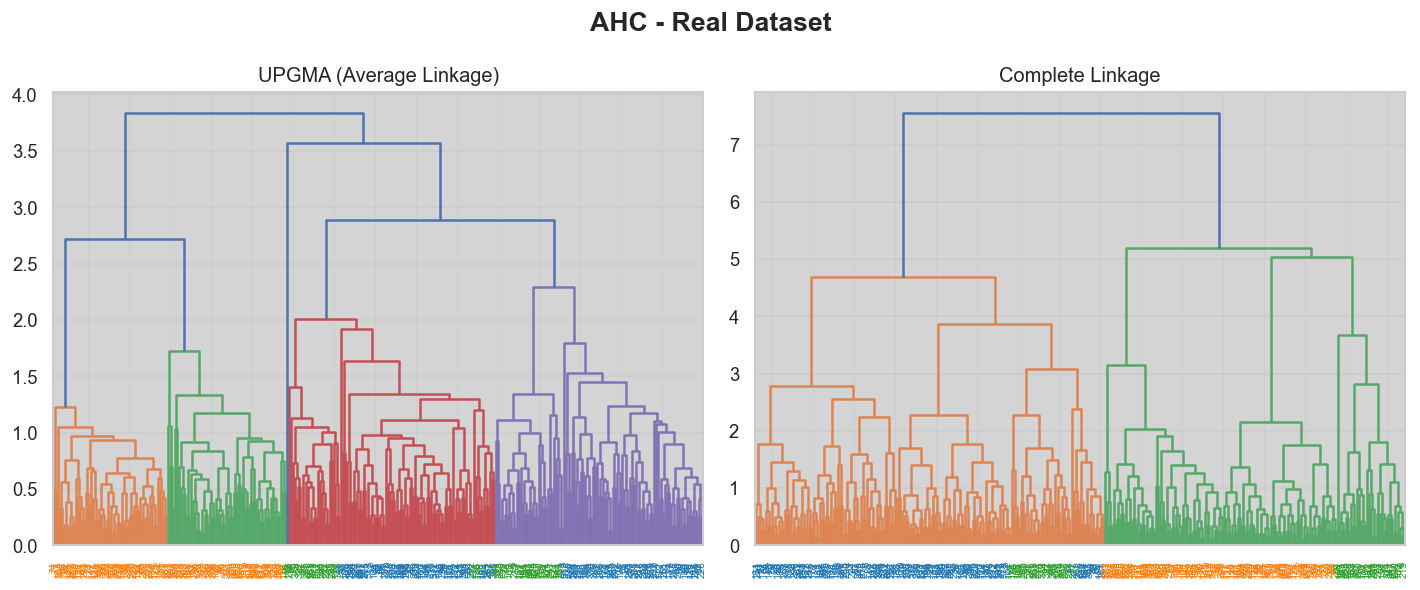

In [9]:
# AHC
from scipy.cluster.hierarchy import linkage, dendrogram
import os

def plot_ahc(X, labels, title, filename):
    """
    Computes Agglomerative Hierarchical Clustering (AHC) and plots the dendrograms.
    The resulting plot is saved in the 'plots' directory with a user-defined filename.
    """
    # 1. Ensure the output directory exists
    if not os.path.exists('plots'):
        os.makedirs('plots')
        
    # 2. Compute the linkage matrices
    Z_avg = linkage(X, method='average', metric='euclidean')
    Z_comp = linkage(X, method='complete', metric='euclidean')
    
    # 3. Setup the figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 4. Configure colors for the true classes
    labels = np.array(labels)
    unique_classes = np.unique(labels)
    palette = sns.color_palette("tab10", len(unique_classes))
    color_map = {cls: palette[i] for i, cls in enumerate(unique_classes)}
    
    def set_leaf_colors(ax):
        """Helper to color the leaf labels based on ground-truth classes."""
        for label in ax.get_xticklabels():
            idx = int(label.get_text())
            label.set_color(color_map[labels[idx]])
    
    # 5. Plot Average Linkage (UPGMA)
    dendrogram(Z_avg, ax=axes[0], labels=np.arange(len(X)), leaf_rotation=90, leaf_font_size=6)
    axes[0].set_title('UPGMA (Average Linkage)')
    set_leaf_colors(axes[0])
    
    # 6. Plot Complete Linkage
    dendrogram(Z_comp, ax=axes[1], labels=np.arange(len(X)), leaf_rotation=90, leaf_font_size=6)
    axes[1].set_title('Complete Linkage')
    set_leaf_colors(axes[1])
    
    # 7. Final layout adjustments
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # 8. Save the figure
    save_path = os.path.join('plots', filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully at: {save_path}")
    
    plt.show()

plot_ahc(
    X=X_syn, 
    labels=meta_syn['labels'], 
    title="AHC - Synthetic Dataset", 
    filename="synthetic_dataset_ahc.png"
)

plot_ahc(
    X=X_real, 
    labels=meta_real['labels'], 
    title="AHC - Real Dataset", 
    filename="real_dataset_ahc.png"
)